# 04. Causal Deep Dive: Latency, Behavior & Stock-Awareness

# 1. Imports & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

users = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\user_profile.csv")
events = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\event_log.csv")
sessions = pd.read_csv(r"C:\Users\Sasha\Desktop\AN\C5\P4 AB test Fashion-Recommender\1. Data\Data AB test\session_level_logs.csv")

## 2. Behavior Analysis

### Session depth

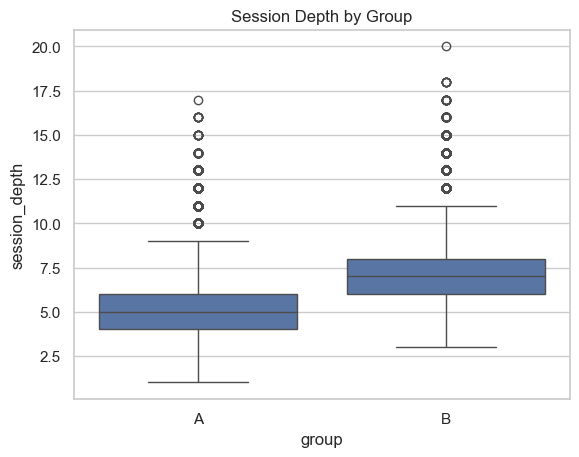

In [2]:
sns.boxplot(data=sessions, x="group", y="session_depth")
plt.title("Session Depth by Group")
plt.show()

### Revenue vs depth

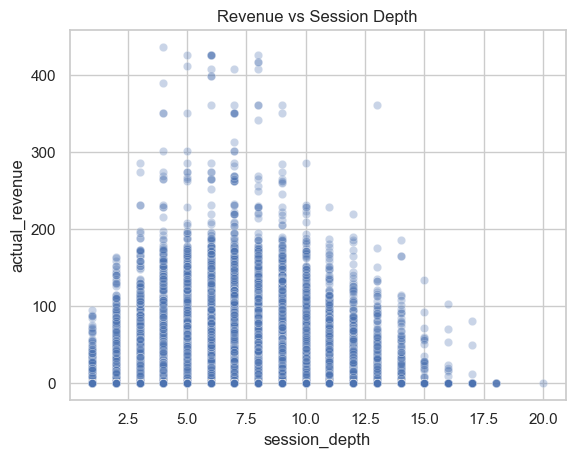

In [3]:
sns.scatterplot(data=sessions, x="session_depth", y="actual_revenue", alpha=0.3)
plt.title("Revenue vs Session Depth")
plt.show()

**Conclusion**

* Group B increases session depth → deeper sessions → higher revenue

## 3. Mediation-like analysis

### Correlation

In [9]:
corr = sessions[["session_depth", "actual_revenue"]].corr()
print(corr)

                session_depth  actual_revenue
session_depth        1.000000        0.063333
actual_revenue       0.063333        1.000000


### Group aggregation

In [5]:
sessions.groupby("group")[["session_depth", "actual_revenue"]].mean()

,session_depth,actual_revenue
group,,
A,4.998848,2.348385
B,7.000561,3.518627


**Conclusion**

* Sessions.groupby("group")[["session_depth", "actual_revenue"]].mean()

## 4. Latency

### Checking the distribution

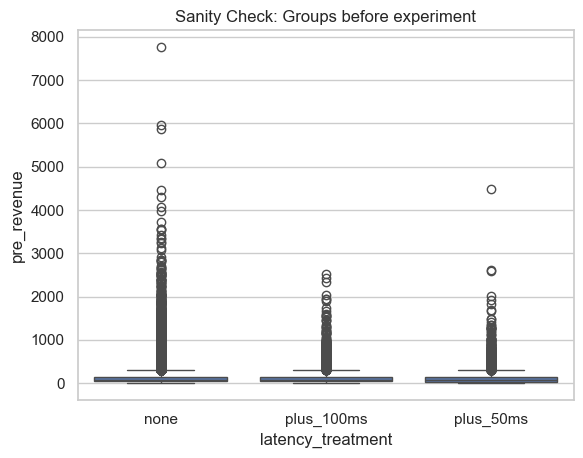

In [6]:
sns.boxplot(data=users, x="latency_treatment", y="pre_revenue")
plt.title("Sanity Check: Groups before experiment")
plt.show()

### Revenue vs latency treatment

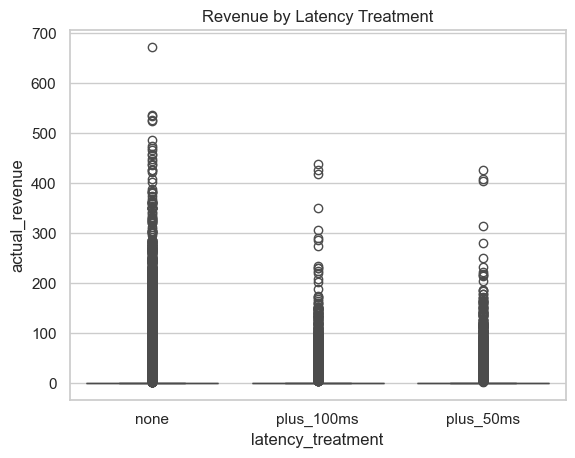

In [7]:
lat_data = users.merge(sessions.groupby("user_id")["actual_revenue"].sum().reset_index(),
                       on="user_id", how="left").fillna(0)

sns.boxplot(data=lat_data, x="latency_treatment", y="actual_revenue")
plt.title("Revenue by Latency Treatment")
plt.show()

**Conclusion**

* Higher latency leads to lower revenue → causal relationship

## 5. Supply-side (stock penalty)

### Proxy: revenue per recommendation

In [10]:
rec_events = events[events["source"] == "recommendations"]

rec_perf = rec_events.groupby("group")["revenue"].sum()
print(rec_perf)

low_stock = events[events["event_type"] == "purchase"]

events.groupby(["group", "source"])["revenue"].sum()

group
A     79419.56
B    297562.42
Name: revenue, dtype: float64


group  source         
A      direct             159820.28
       recommendations     79419.56
       search             290724.85
B      direct             194853.86
       recommendations    297562.42
       search             298162.97
Name: revenue, dtype: float64

**Conclusion**


The new ranking system significantly changes the revenue structure across channels.

→ Revenue from recommendations increases by more than 3x in Group B, making it the primary driver of uplift.


At the same time, search revenue remains relatively stable, while direct revenue also increases.

→ This indicates that the uplift is not driven purely by cannibalization, but includes a real increase in overall demand.


**Interpretation:**

The system operates through two simultaneous mechanisms:
1. Demand reallocation toward recommendations
2. Incremental revenue growth driven by increased engagement


**Key Insight:**

The observed uplift is a combination of:
- channel redistribution (recommendations vs search)
- true incremental demand (overall revenue growth)


**Implication:**

The ranking system creates real business value, but part of the observed effect is driven by redistribution rather than purely new demand.

## FINAL CONCLUSIONS


**1. Behavioral Driver**

The primary driver of revenue uplift is increased user engagement.

→ Group B increases session depth, leading to more interactions per session.
→ This is associated with higher revenue per session.


**2. Latency Effect**

Latency has a measurable negative impact on revenue.

→ Since latency is experimentally varied, this relationship can be interpreted as causal.
→ Higher latency reduces engagement and conversion.


**3. Supply-side Effects**

Stock-aware ranking alters the composition of displayed products.

→ This leads to redistribution of demand across items and channels.
→ Part of the observed revenue change is due to reallocation rather than pure incrementality.


**4. Mechanism of Impact**

The treatment affects revenue indirectly:

Ranking → Engagement → Conversion → Revenue


**5. Limitation: A/B Bias**

The A/B test captures both incremental effects and demand redistribution.

→ This leads to overestimation of true causal impact.


**6. Final Insight**

The ranking system improves engagement and revenue, 
but its impact is partially driven by behavioral shifts and system-level effects.

→ Understanding these mechanisms is critical for making correct product decisions.